# Benchmark Results Visualization

This notebook reads the JSON outputs generated by `metrics_parser.py` and compiles them into the tables and plots required by the project's benchmarking protocol (Part E).

### Required Outputs:
- **Table**: Runtime, #Stages, #Tasks, ShuffleRead (MB), ShuffleWrite (MB), PeakMemory (Driver/Exec), DriverTime.
- **Plot**: Runtime (mean±std) across configurations.
- **Plot**: Shuffle Read/Write (MB) across configurations.

### Additional Outputs:
- **Plot**: #Stages and #Tasks across configurations.
- **Plot**: Driver Time across configurations.
- **Plot**: Peak Memory across configurations.
- **Plot**: Speedup relative to baseline.
- **Export**: Summary table as CSV and LaTeX.

In [1]:
import json
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the logical order of configurations.
# Add new configuration names here as they are benchmarked.
CONFIG_ORDER = ["baseline", "v2", "v3", "v4", "v5", "v6", "v7", "final"]

# Output directory for all plots, CSV, and LaTeX
PLOTS_DIR = "../plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Metrics JSONs live in ../metrics/ relative to this notebook (jobs/)
json_files = glob.glob("../metrics/*.json")

print(f"Found {len(json_files)} metric configuration files: {json_files}")

# Load and sort by CONFIG_ORDER
raw_jsons = []
for f in json_files:
    try:
        with open(f, 'r') as file:
            raw_jsons.append(json.load(file))
    except Exception as e:
        print(f"Could not process {f}: {e}")

def config_sort_key(js):
    name = js['summary']['config']
    try:
        return CONFIG_ORDER.index(name)
    except ValueError:
        return len(CONFIG_ORDER)  # unknown configs go to the end

raw_jsons.sort(key=config_sort_key)
configs = [js['summary']['config'] for js in raw_jsons]
print(f"Configurations (ordered): {configs}")

Found 8 metric configuration files: ['../metrics\\baseline.json', '../metrics\\final.json', '../metrics\\v2.json', '../metrics\\v3.json', '../metrics\\v4.json', '../metrics\\v5.json', '../metrics\\v6.json', '../metrics\\v7.json']
Configurations (ordered): ['baseline', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'final']


In [2]:
# 1. Summary Table

def safe_std(std_dict, key):
    """Return std value, replacing NaN with 0 (happens when n_runs=1)."""
    v = std_dict.get(key, 0)
    return v if v == v else 0  # NaN != NaN

data = []
for js in raw_jsons:
    mean = js['summary']['mean']
    std = js['summary']['std']
    config_name = js['summary']['config']

    data.append({
        "Configuration": config_name,
        "Runtime (s)": f"{mean.get('wall_time_s',0):.2f} ± {safe_std(std, 'wall_time_s'):.2f}",
        "# Stages": f"{mean.get('stages',0):.1f}",
        "# Tasks": f"{mean.get('tasks',0):.1f}",
        "Shuffle Read (MB)": f"{mean.get('shuffle_read_mb',0):.2f} ± {safe_std(std, 'shuffle_read_mb'):.2f}",
        "Shuffle Write (MB)": f"{mean.get('shuffle_write_mb',0):.2f} ± {safe_std(std, 'shuffle_write_mb'):.2f}",
        "Peak Memory (MB)": f"{mean.get('peak_memory_mb',0):.2f} ± {safe_std(std, 'peak_memory_mb'):.2f}",
        "Driver Time (s)": f"{mean.get('driver_time_s',0):.2f} ± {safe_std(std, 'driver_time_s'):.2f}",
    })

df_table = pd.DataFrame(data)
display(df_table)

# Export to CSV and LaTeX
df_table.to_csv(f"{PLOTS_DIR}/benchmark_summary.csv", index=False)
print(f"Saved {PLOTS_DIR}/benchmark_summary.csv")

latex_str = df_table.to_latex(index=False, caption="Benchmark results across configurations.", label="tab:benchmark")
with open(f"{PLOTS_DIR}/benchmark_summary.tex", "w") as f:
    f.write(latex_str)
print(f"Saved {PLOTS_DIR}/benchmark_summary.tex")

,Configuration,Runtime (s),# Stages,# Tasks,Shuffle Read (MB),Shuffle Write (MB),Peak Memory (MB),Driver Time (s)
0,baseline,66.10 ± 0.40,77.0,135.0,0.02 ± 0.00,0.02 ± 0.00,3936.73 ± 379.26,20.73 ± 0.40
1,v2,52.38 ± 0.61,55.0,55.0,0.01 ± 0.00,0.01 ± 0.00,3322.44 ± 9.98,20.67 ± 0.61
2,v3,50.07 ± 0.31,50.0,50.0,0.01 ± 0.00,0.01 ± 0.00,3680.15 ± 69.10,20.53 ± 0.31
3,v4,42.12 ± 0.03,53.0,53.0,0.01 ± 0.00,0.01 ± 0.00,3686.02 ± 7.00,20.68 ± 0.03
4,v5,40.11 ± 0.49,53.0,53.0,0.01 ± 0.00,0.01 ± 0.00,3358.85 ± 84.13,20.52 ± 0.49
5,v6,39.12 ± 0.20,47.0,47.0,0.00 ± 0.00,0.00 ± 0.00,3372.23 ± 74.40,20.57 ± 0.20
6,v7,33.82 ± 0.39,23.0,23.0,0.00 ± 0.00,0.00 ± 0.00,3374.50 ± 48.71,20.66 ± 0.39
7,final,31.59 ± 0.06,11.0,11.0,0.00 ± 0.00,0.00 ± 0.00,3355.98 ± 117.25,20.45 ± 0.06


Saved ../plots/benchmark_summary.csv
Saved ../plots/benchmark_summary.tex


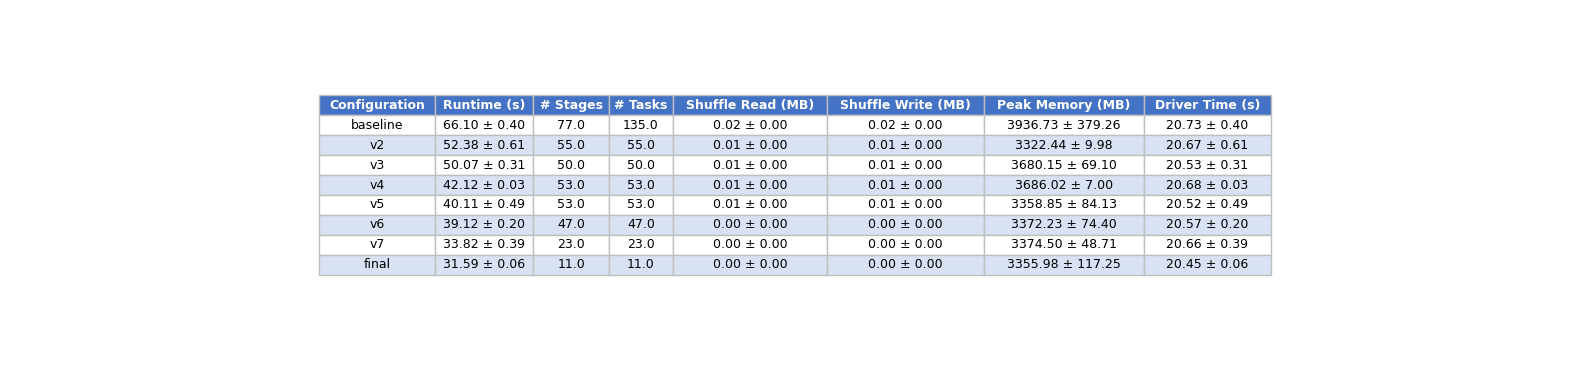

Saved ../plots/table_summary.png


In [3]:
# 1b. Export summary table as image
fig, ax = plt.subplots(figsize=(16, 0.6 + 0.4 * len(df_table)))
ax.axis('off')

table = ax.table(
    cellText=df_table.values,
    colLabels=df_table.columns,
    cellLoc='center',
    loc='center',
)

table.auto_set_font_size(False)
table.set_fontsize(9)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4472C4')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#D9E2F3')
    else:
        cell.set_facecolor('#FFFFFF')
    cell.set_edgecolor('#BFBFBF')

table.auto_set_column_width(col=list(range(len(df_table.columns))))
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/table_summary.png", dpi=200, bbox_inches='tight', pad_inches=0.1)
plt.show()
print(f"Saved {PLOTS_DIR}/table_summary.png")

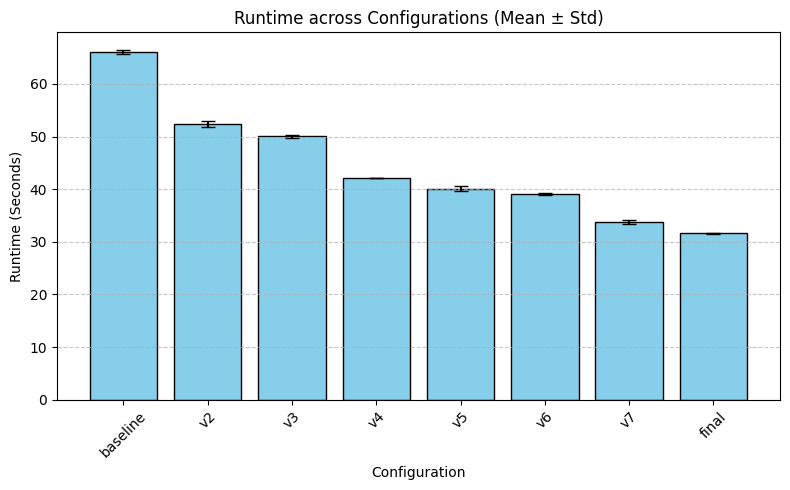

In [4]:
# 2. Plot: Runtime (mean ± std) across configurations
if raw_jsons:
    runtimes = [js['summary']['mean'].get('wall_time_s', 0) for js in raw_jsons]
    runtimes_err = [safe_std(js['summary']['std'], 'wall_time_s') for js in raw_jsons]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(configs, runtimes, yerr=runtimes_err, capsize=5, color='skyblue', edgecolor='black')
    ax.set_ylabel('Runtime (Seconds)')
    ax.set_xlabel('Configuration')
    ax.set_title('Runtime across Configurations (Mean ± Std)')
    plt.xticks(rotation=45)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/plot_runtime.png", dpi=150)
    plt.show()
else:
    print("No data available to plot.")

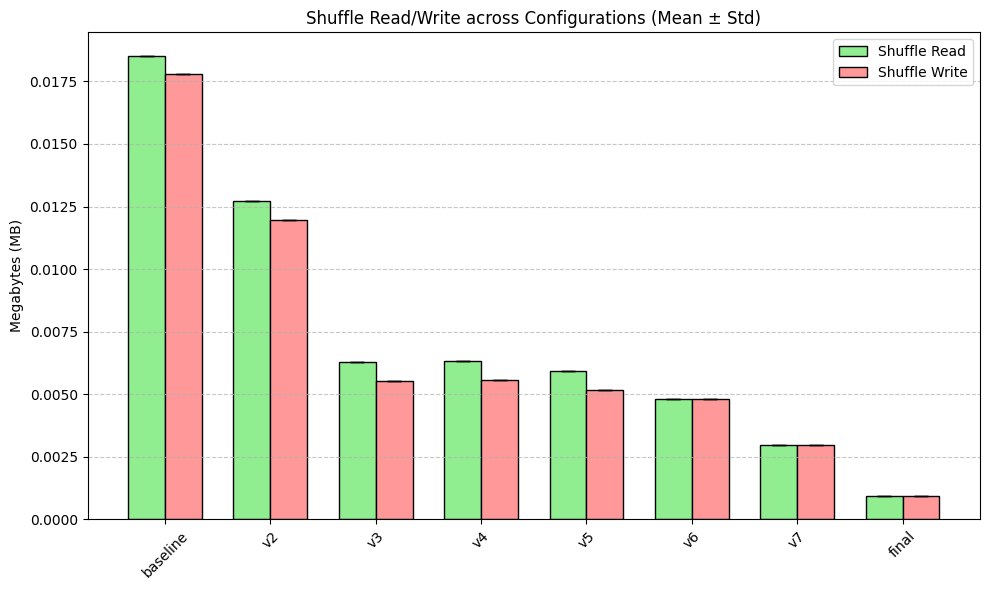

In [5]:
# 3. Plot: Shuffle Read/Write (MB) across configurations
if raw_jsons:
    read_means = [js['summary']['mean'].get('shuffle_read_mb', 0) for js in raw_jsons]
    read_errs = [safe_std(js['summary']['std'], 'shuffle_read_mb') for js in raw_jsons]
    write_means = [js['summary']['mean'].get('shuffle_write_mb', 0) for js in raw_jsons]
    write_errs = [safe_std(js['summary']['std'], 'shuffle_write_mb') for js in raw_jsons]

    x = np.arange(len(configs))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, read_means, width, yerr=read_errs, label='Shuffle Read', capsize=5, color='#90EE90', edgecolor='black')
    ax.bar(x + width/2, write_means, width, yerr=write_errs, label='Shuffle Write', capsize=5, color='#FF9999', edgecolor='black')
    ax.set_ylabel('Megabytes (MB)')
    ax.set_title('Shuffle Read/Write across Configurations (Mean ± Std)')
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=45)
    ax.legend()
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/plot_shuffle.png", dpi=150)
    plt.show()
else:
    print("No data available to plot.")

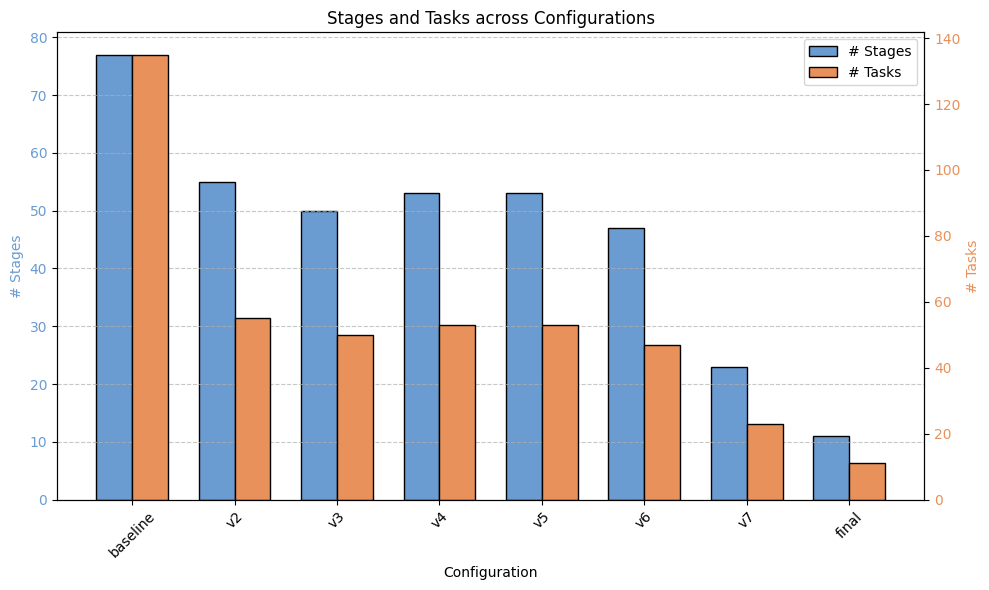

In [6]:
# 4. Plot: #Stages and #Tasks across configurations
if raw_jsons:
    stages = [js['summary']['mean'].get('stages', 0) for js in raw_jsons]
    tasks = [js['summary']['mean'].get('tasks', 0) for js in raw_jsons]

    x = np.arange(len(configs))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(10, 6))

    color_stages = '#6A9BD1'
    color_tasks = '#E8915A'

    bars1 = ax1.bar(x - width/2, stages, width, label='# Stages', color=color_stages, edgecolor='black')
    ax1.set_ylabel('# Stages', color=color_stages)
    ax1.tick_params(axis='y', labelcolor=color_stages)

    # Use a second y-axis for tasks (typically much larger numbers)
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, tasks, width, label='# Tasks', color=color_tasks, edgecolor='black')
    ax2.set_ylabel('# Tasks', color=color_tasks)
    ax2.tick_params(axis='y', labelcolor=color_tasks)

    ax1.set_xlabel('Configuration')
    ax1.set_title('Stages and Tasks across Configurations')
    ax1.set_xticks(x)
    ax1.set_xticklabels(configs, rotation=45)
    ax1.yaxis.grid(True, linestyle='--', alpha=0.7)

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/plot_stages_tasks.png", dpi=150)
    plt.show()
else:
    print("No data available to plot.")

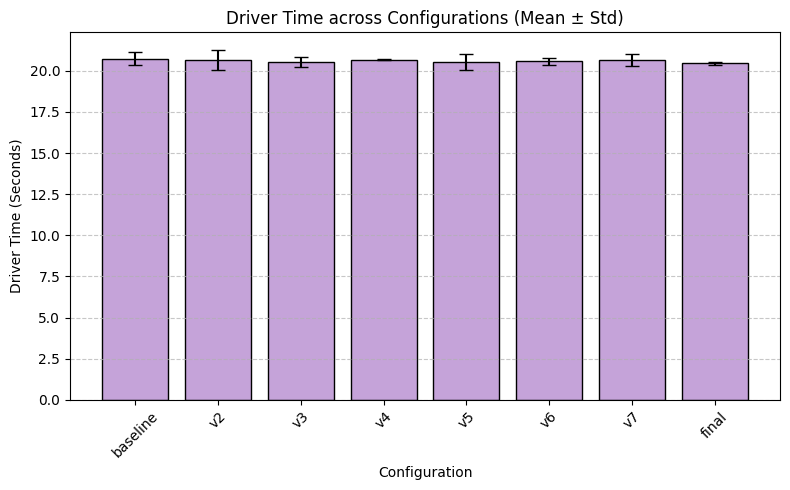

In [7]:
# 5. Plot: Driver Time (mean ± std) across configurations
if raw_jsons:
    driver_times = [js['summary']['mean'].get('driver_time_s', 0) for js in raw_jsons]
    driver_errs = [safe_std(js['summary']['std'], 'driver_time_s') for js in raw_jsons]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(configs, driver_times, yerr=driver_errs, capsize=5, color='#C5A3D9', edgecolor='black')
    ax.set_ylabel('Driver Time (Seconds)')
    ax.set_xlabel('Configuration')
    ax.set_title('Driver Time across Configurations (Mean ± Std)')
    plt.xticks(rotation=45)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/plot_driver_time.png", dpi=150)
    plt.show()
else:
    print("No data available to plot.")

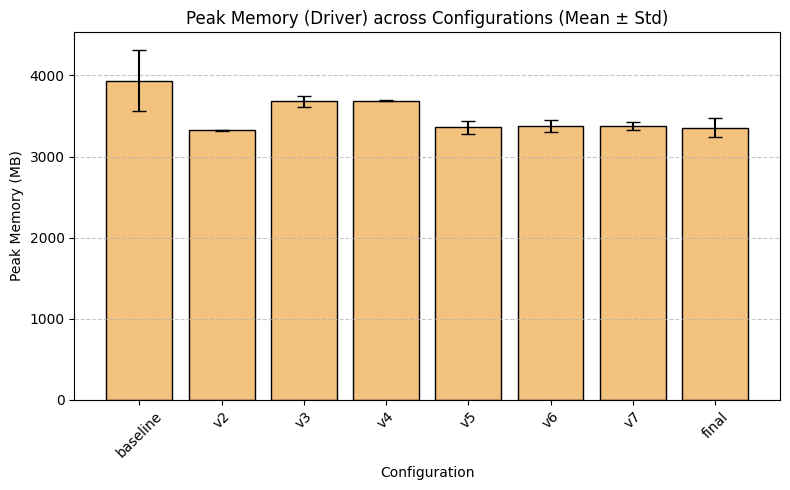

In [8]:
# 6. Plot: Peak Memory (mean ± std) across configurations
if raw_jsons:
    mem_means = [js['summary']['mean'].get('peak_memory_mb', 0) for js in raw_jsons]
    mem_errs = [safe_std(js['summary']['std'], 'peak_memory_mb') for js in raw_jsons]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(configs, mem_means, yerr=mem_errs, capsize=5, color='#F4C27F', edgecolor='black')
    ax.set_ylabel('Peak Memory (MB)')
    ax.set_xlabel('Configuration')
    ax.set_title('Peak Memory (Driver) across Configurations (Mean ± Std)')
    plt.xticks(rotation=45)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/plot_peak_memory.png", dpi=150)
    plt.show()
else:
    print("No data available to plot.")

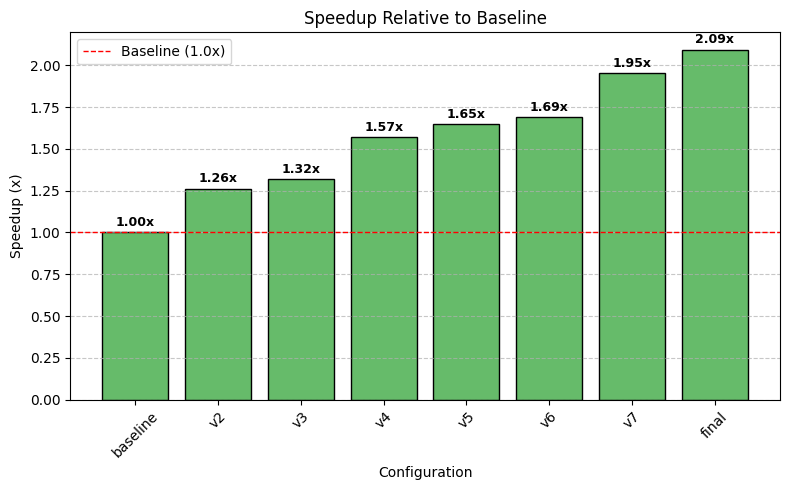

In [9]:
# 7. Plot: Speedup relative to baseline
if raw_jsons:
    baseline_runtime = raw_jsons[0]['summary']['mean'].get('wall_time_s', 1)
    speedups = [baseline_runtime / js['summary']['mean'].get('wall_time_s', 1) for js in raw_jsons]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(configs, speedups, color='#66BB6A', edgecolor='black')
    ax.axhline(y=1, color='red', linestyle='--', linewidth=1, label='Baseline (1.0x)')
    ax.set_ylabel('Speedup (x)')
    ax.set_xlabel('Configuration')
    ax.set_title('Speedup Relative to Baseline')
    plt.xticks(rotation=45)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

    # Annotate each bar with the speedup value
    for bar, sp in zip(bars, speedups):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{sp:.2f}x', ha='center', va='bottom', fontweight='bold', fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/plot_speedup.png", dpi=150)
    plt.show()
else:
    print("No data available to plot.")